# Netflix Content Analytics & Executive Dashboard

**A complete, end-to-end analytics engagement built on the Netflix Movies and TV Shows dataset (Kaggle).**

This notebook is the reproducible source of truth behind the accompanying PDF report and Power BI dashboard.
It covers the full analytics lifecycle:

1. Import Libraries
2. Load Dataset
3. Data Overview
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Statistical Analysis
8. Dashboard Preparation
9. Business Insights
10. Recommendations
11. Conclusion

**Dataset:** `netflix_titles.csv` — 8,807 Netflix titles (Movies & TV Shows), sourced from Kaggle.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sps
from wordcloud import WordCloud
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

NETFLIX_RED = "#E50914"
DARK = "#221F1F"
sns.set_theme(style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
print("Libraries loaded.")

Libraries loaded.


## 2. Load Dataset

In [2]:
df_raw = pd.read_csv("netflix_titles.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Data Overview

Before cleaning anything, we profile the raw dataset: shape, dtypes, missing values, and duplicates.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [5]:
dupe_count = df_raw.duplicated(subset=["title", "type", "release_year"]).sum()
print(f"Duplicate titles (by title/type/release_year): {dupe_count}")

Duplicate titles (by title/type/release_year): 0


In [6]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

We apply a systematic cleaning pipeline:
- Remove duplicates
- Fill/handle missing values (preserving records where possible)
- Fix a known data quirk where `rating` and `duration` values are swapped for a handful of rows
- Convert `date_added` to a proper datetime
- Drop rows with unrecoverable missing dates (required for time-series analysis)

In [7]:
df = df_raw.copy()

# --- Remove duplicates ---
before = len(df)
df = df.drop_duplicates(subset=["title", "type", "release_year"]).reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows")

# --- Fill categorical missing values ---
df["director"] = df["director"].fillna("Not Specified")
df["cast"] = df["cast"].fillna("Not Specified")
df["country"] = df["country"].fillna("Not Specified")

# --- Fix known rating/duration swap quirk ---
swap_mask = df["rating"].astype(str).str.contains(r"\d+\s*min", na=False)
df.loc[swap_mask, "duration"] = df.loc[swap_mask, "rating"]
df.loc[swap_mask, "rating"] = np.nan
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# --- Drop rows with missing date_added (needed for time-series analysis) ---
df = df.dropna(subset=["date_added"]).reset_index(drop=True)

print(f"Rows remaining: {len(df)} of {len(df_raw)}")
df.isna().sum()

Removed 0 duplicate rows
Rows remaining: 8797 of 8807


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
# --- Convert date_added to datetime ---
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y", errors="coerce")
df = df.dropna(subset=["date_added"]).reset_index(drop=True)
print(df["date_added"].min(), "to", df["date_added"].max())

2008-01-01 00:00:00 to 2021-09-25 00:00:00


## 5. Feature Engineering

We derive analysis-ready features from the raw text fields: dates, multi-value list columns, numeric
durations, and simplified audience-rating groups.

In [9]:
# Date-derived features
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name_added"] = df["date_added"].dt.strftime("%B")

# Duration split by content type
def parse_duration(row):
    m = pd.Series(row["duration"]).str.extract(r"(\d+)")[0]
    num = float(m.iloc[0]) if pd.notna(m.iloc[0]) else np.nan
    if row["type"] == "Movie":
        return pd.Series([num, np.nan])
    return pd.Series([np.nan, num])

df[["duration_minutes", "duration_seasons"]] = df.apply(parse_duration, axis=1)

# Country / genre / cast / director parsing
df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip() if x != "Not Specified" else "Not Specified")
df["genre_list"] = df["listed_in"].apply(lambda x: [g.strip() for g in x.split(",")])
df["primary_genre"] = df["genre_list"].apply(lambda x: x[0])
df["n_genres"] = df["genre_list"].apply(len)
df["cast_list"] = df["cast"].apply(lambda x: [] if x == "Not Specified" else [c.strip() for c in x.split(",")])
df["n_cast"] = df["cast_list"].apply(len)
df["director_list"] = df["director"].apply(lambda x: [] if x == "Not Specified" else [d.strip() for d in x.split(",")])

# Licensing-lag & decade features
df["years_between_release_and_add"] = df["year_added"] - df["release_year"]
df["release_decade"] = (df["release_year"] // 10) * 10

# Simplified rating group
rating_map = {
    "G": "Kids/Family", "TV-Y": "Kids/Family", "TV-Y7": "Kids/Family", "TV-Y7-FV": "Kids/Family",
    "TV-G": "Kids/Family", "PG": "Family/Teens", "TV-PG": "Family/Teens",
    "PG-13": "Teens", "TV-14": "Teens",
    "R": "Adults", "TV-MA": "Adults", "NC-17": "Adults",
    "NR": "Not Rated", "UR": "Not Rated",
}
df["rating_group"] = df["rating"].map(rating_map).fillna("Not Rated")

print(f"Engineered dataset shape: {df.shape}")
df.head()

Engineered dataset shape: (8797, 27)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name_added,duration_minutes,duration_seasons,primary_country,genre_list,primary_genre,n_genres,cast_list,n_cast,director_list,years_between_release_and_add,release_decade,rating_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,90.0,NaN,United States,[Documentaries],Documentaries,1,[],0,[Kirsten Johnson],1,2020,Teens
1,s2,TV Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,NaN,2.0,South Africa,"[International TV Shows, TV Dramas, TV Mysteries]",International TV Shows,3,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",19,[],0,2020,Adults
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,NaN,1.0,Not Specified,"[Crime TV Shows, International TV Shows, TV Ac...",Crime TV Shows,3,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",9,[Julien Leclercq],0,2020,Adults
3,s4,TV Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,NaN,1.0,Not Specified,"[Docuseries, Reality TV]",Docuseries,2,[],0,[],0,2020,Adults
4,s5,TV Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,NaN,2.0,India,"[International TV Shows, Romantic TV Shows, TV...",International TV Shows,3,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",8,[],0,2020,Adults


In [10]:
df.to_csv("netflix_titles_clean.csv", index=False)
print("Saved cleaned dataset -> netflix_titles_clean.csv")

Saved cleaned dataset -> netflix_titles_clean.csv


## 6. Exploratory Data Analysis

We now visualize the cleaned dataset across growth trends, geography, genre, cast/crew, ratings, and duration.
Each chart in this section corresponds directly to a figure in the PDF report.

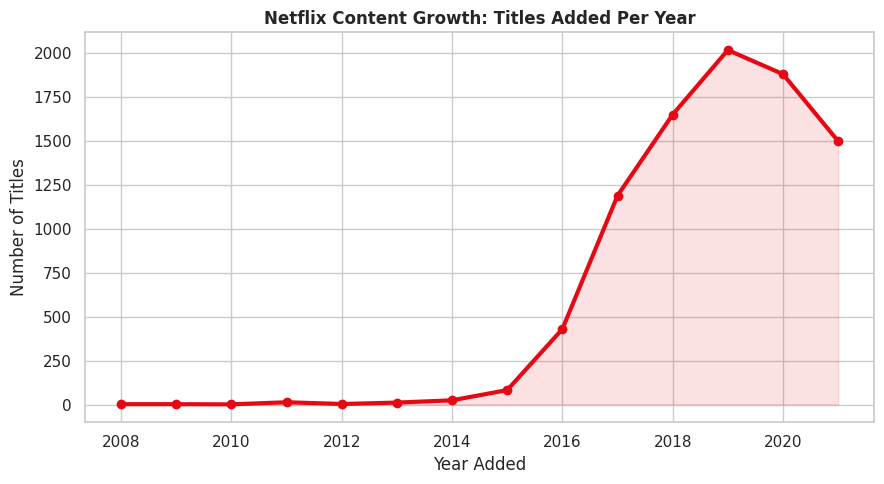

In [11]:
# Content growth over time
yearly = df[df["year_added"] <= 2021]["year_added"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly.index, yearly.values, color=NETFLIX_RED, linewidth=3, marker="o")
ax.fill_between(yearly.index, yearly.values, color=NETFLIX_RED, alpha=0.12)
ax.set_title("Netflix Content Growth: Titles Added Per Year")
ax.set_xlabel("Year Added"); ax.set_ylabel("Number of Titles")
plt.tight_layout(); plt.show()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64
type
Movie      69.7
TV Show    30.3
Name: count, dtype: float64


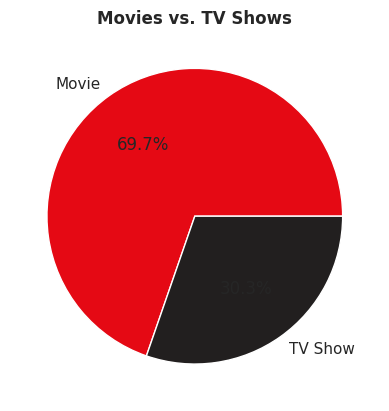

In [12]:
# Movies vs TV Shows
type_counts = df["type"].value_counts()
print(type_counts)
print((type_counts / type_counts.sum() * 100).round(1))
type_counts.plot(kind="pie", autopct="%1.1f%%", colors=[NETFLIX_RED, DARK], ylabel="")
plt.title("Movies vs. TV Shows")
plt.show()

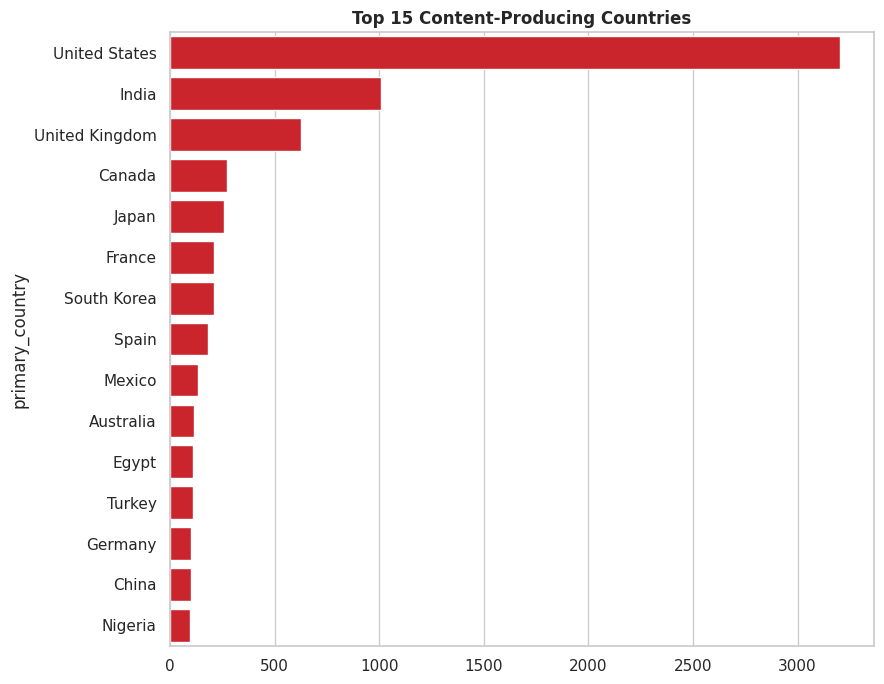

In [13]:
# Top content-producing countries
top_countries = df[df["primary_country"] != "Not Specified"]["primary_country"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Top 15 Content-Producing Countries")
plt.tight_layout(); plt.show()

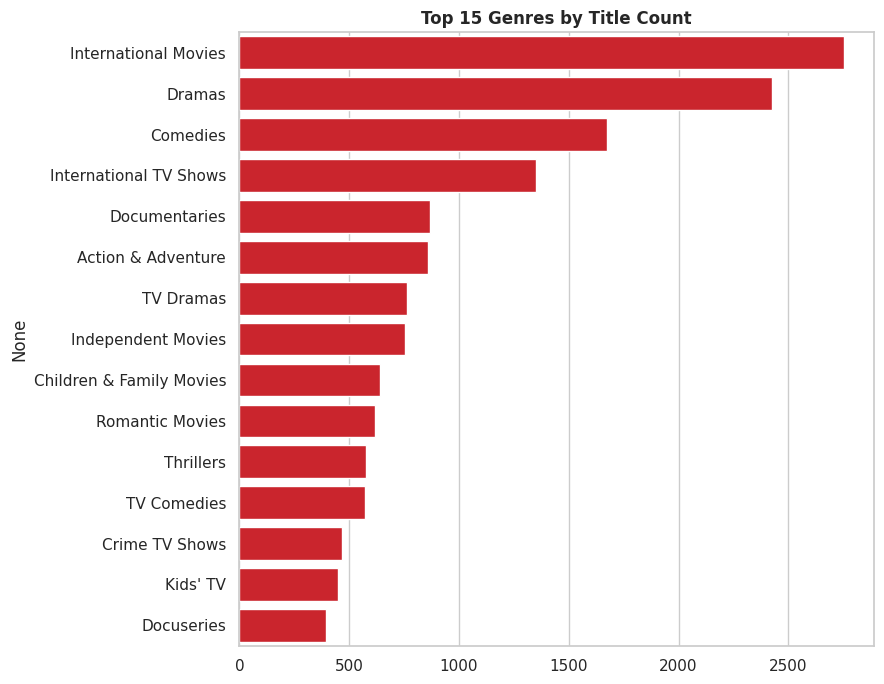

In [14]:
# Top genres
all_genres = pd.Series([g for sub in df["genre_list"] for g in sub])
top_genres = all_genres.value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Top 15 Genres by Title Count")
plt.tight_layout(); plt.show()

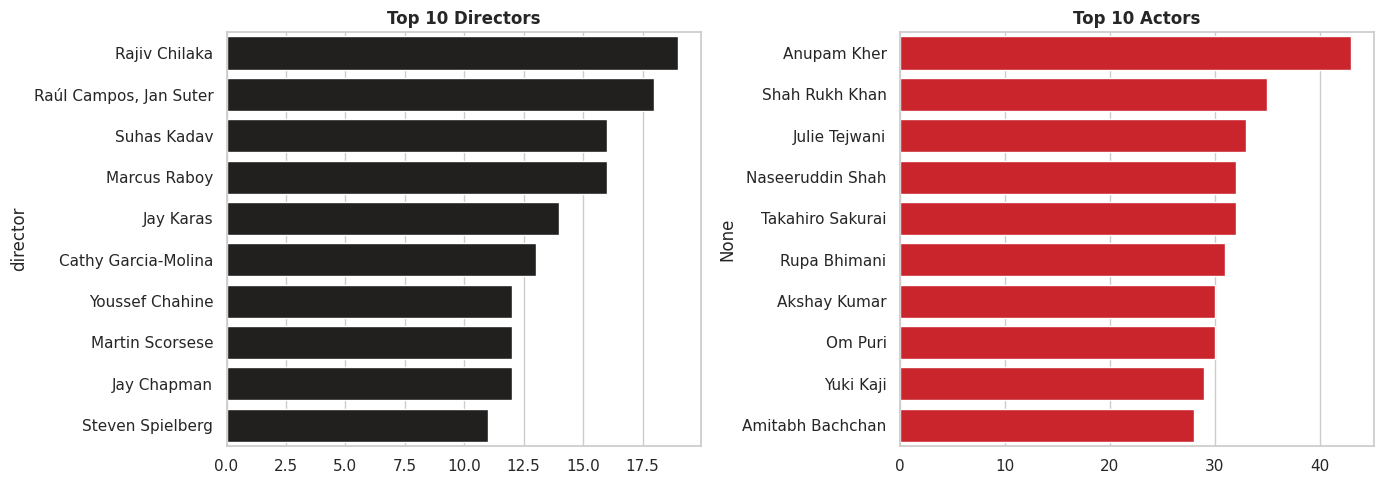

In [15]:
# Top directors and actors
top_directors = df[df["director"] != "Not Specified"]["director"].value_counts().head(10)
all_actors = pd.Series([a for sub in df["cast_list"] for a in sub if a != "Not Specified"])
top_actors = all_actors.value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, color=DARK, ax=axes[0])
axes[0].set_title("Top 10 Directors")
sns.barplot(x=top_actors.values, y=top_actors.index, color=NETFLIX_RED, ax=axes[1])
axes[1].set_title("Top 10 Actors")
plt.tight_layout(); plt.show()

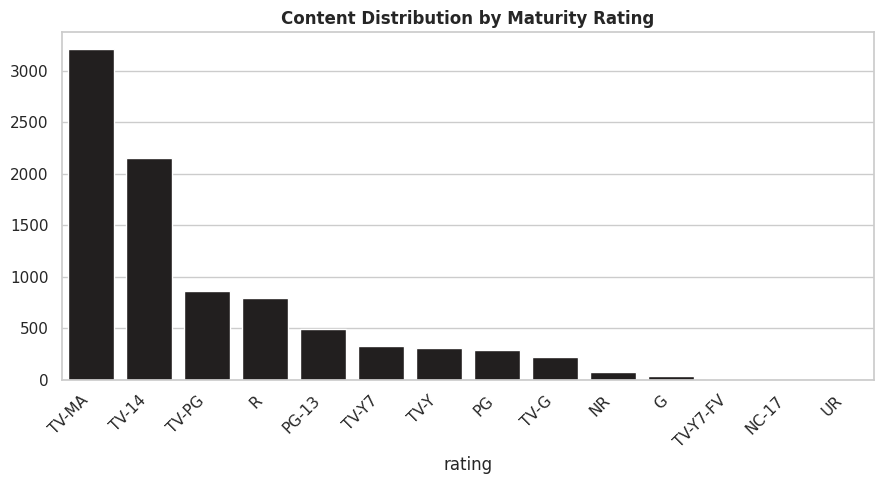

In [16]:
# Rating distribution
rating_counts = df["rating"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color=DARK, order=rating_counts.index, ax=ax)
plt.xticks(rotation=45, ha="right")
ax.set_title("Content Distribution by Maturity Rating")
plt.tight_layout(); plt.show()

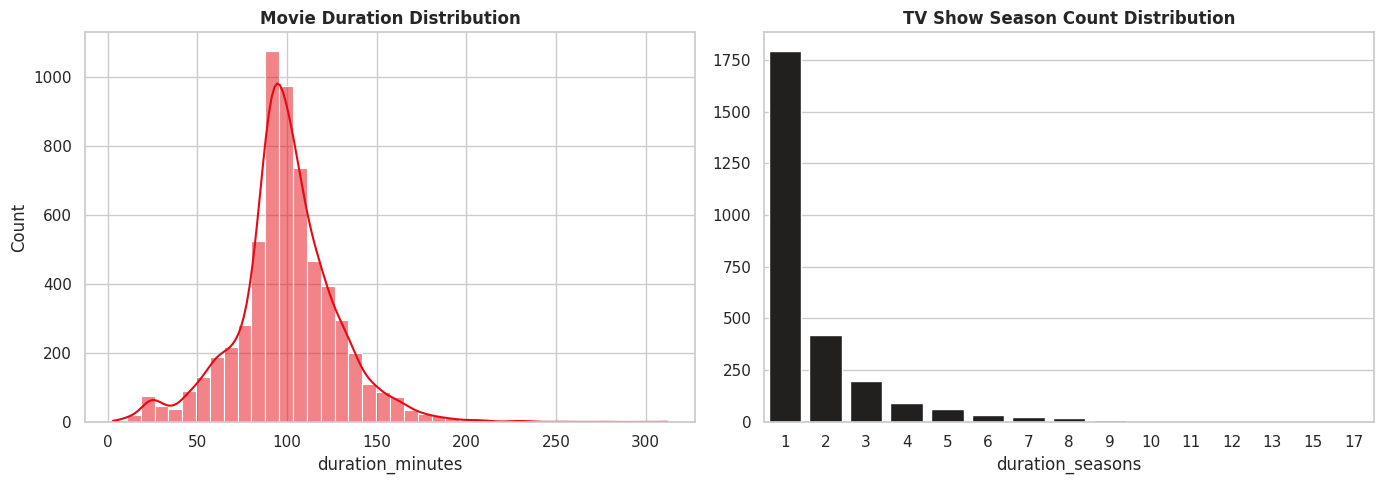

In [17]:
# Movie duration & TV season distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df["type"]=="Movie"]["duration_minutes"].dropna(), bins=40, color=NETFLIX_RED, kde=True, ax=axes[0])
axes[0].set_title("Movie Duration Distribution")
season_counts = df[df["type"]=="TV Show"]["duration_seasons"].dropna().value_counts().sort_index()
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, color=DARK, ax=axes[1])
axes[1].set_title("TV Show Season Count Distribution")
plt.tight_layout(); plt.show()

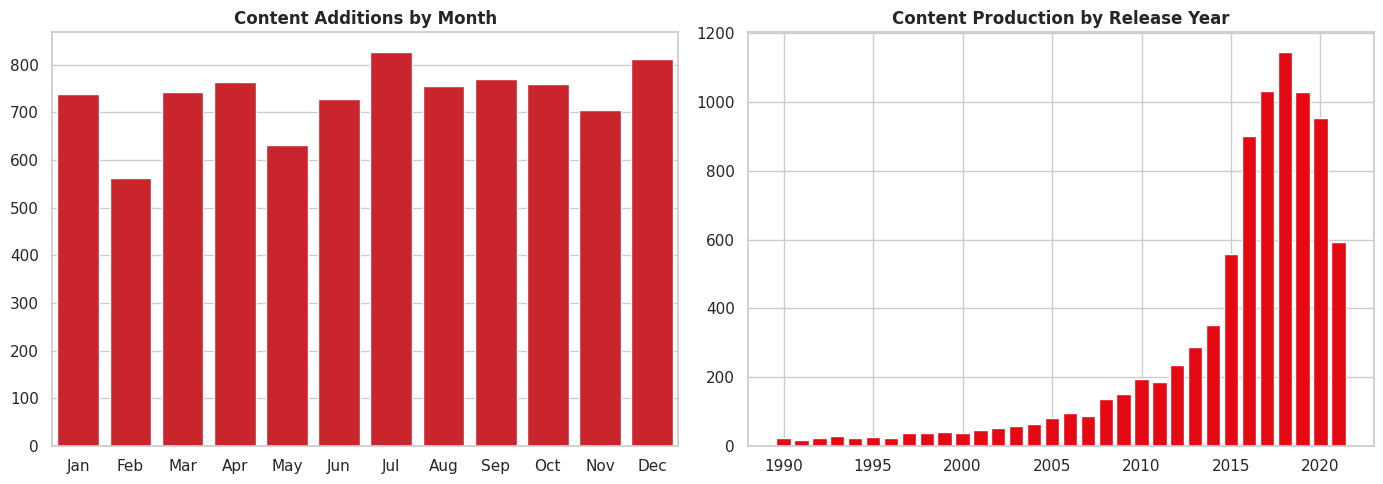

In [18]:
# Monthly seasonality & yearly release volume
month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
monthly = df.groupby("month_name_added").size().reindex(month_order)
release_yearly = df[df["release_year"] >= 1990]["release_year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=[m[:3] for m in month_order], y=monthly.values, color=NETFLIX_RED, ax=axes[0])
axes[0].set_title("Content Additions by Month")
axes[1].bar(release_yearly.index, release_yearly.values, color=NETFLIX_RED)
axes[1].set_title("Content Production by Release Year")
plt.tight_layout(); plt.show()

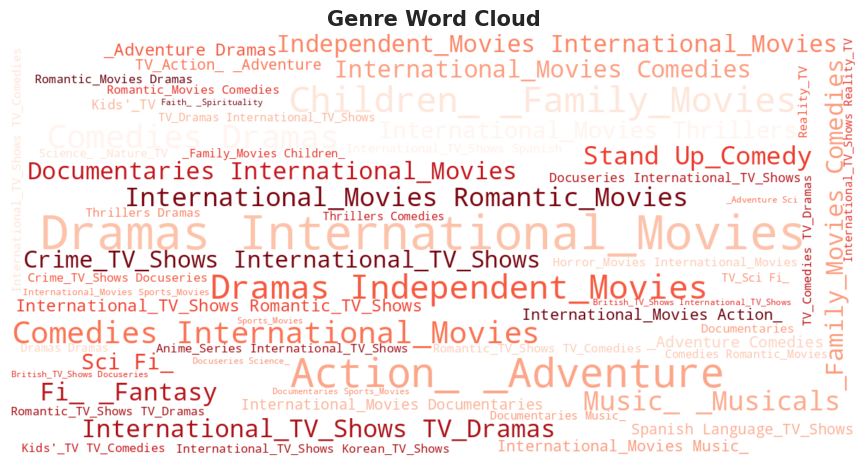

In [19]:
# Genre word cloud
genre_text = " ".join(all_genres.str.replace(" ", "_"))
wc = WordCloud(width=1200, height=600, background_color="white", colormap="Reds", max_words=60).generate(genre_text)
plt.figure(figsize=(11, 5.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Genre Word Cloud", fontsize=15, fontweight="bold")
plt.show()

## 7. Statistical Analysis

We move beyond visual exploration to formal hypothesis testing (&alpha; = 0.05).

In [20]:
# Chi-square: content type vs. rating group
ct = pd.crosstab(df["type"], df["rating_group"])
chi2, p, dof, expected = sps.chi2_contingency(ct)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p:.2e}")
print("Significant association" if p < 0.05 else "No significant association")

Chi-square = 230.62, dof = 4, p-value = 9.69e-49
Significant association


In [21]:
# Chi-square: country (top 5) vs. type
top5c = df[df["primary_country"] != "Not Specified"]["primary_country"].value_counts().head(5).index
sub = df[df["primary_country"].isin(top5c)]
ct2 = pd.crosstab(sub["primary_country"], sub["type"])
chi2b, pb, dofb, _ = sps.chi2_contingency(ct2)
print(f"Chi-square = {chi2b:.2f}, dof = {dofb}, p-value = {pb:.2e}")

Chi-square = 447.87, dof = 4, p-value = 1.25e-95


In [22]:
# Correlation: release year vs. movie duration
movies = df[df["type"] == "Movie"].dropna(subset=["duration_minutes"])
r, p_r = sps.pearsonr(movies["release_year"], movies["duration_minutes"])
print(f"Pearson r = {r:.3f}, p-value = {p_r:.2e}")

Pearson r = -0.206, p-value = 6.40e-60


In [23]:
# T-test: US vs non-US movie duration
us_movies = movies[movies["primary_country"] == "United States"]["duration_minutes"]
non_us_movies = movies[(movies["primary_country"] != "United States") & (movies["primary_country"] != "Not Specified")]["duration_minutes"]
t_stat, p_t = sps.ttest_ind(us_movies, non_us_movies, equal_var=False)
print(f"t = {t_stat:.3f}, p-value = {p_t:.2e}")
print(f"US mean: {us_movies.mean():.1f} min | Non-US mean: {non_us_movies.mean():.1f} min")

t = -21.044, p-value = 1.79e-94
US mean: 92.0 min | Non-US mean: 106.6 min


In [24]:
# ANOVA: movie duration across rating groups
groups = [g["duration_minutes"].dropna().values for _, g in movies.groupby("rating_group")]
f_stat, p_f = sps.f_oneway(*groups)
print(f"F = {f_stat:.3f}, p-value = {p_f:.2e}")

F = 247.863, p-value = 1.21e-197


IQR bounds: [46.5, 154.5] minutes
Outliers: 450 (7.34% of movies)


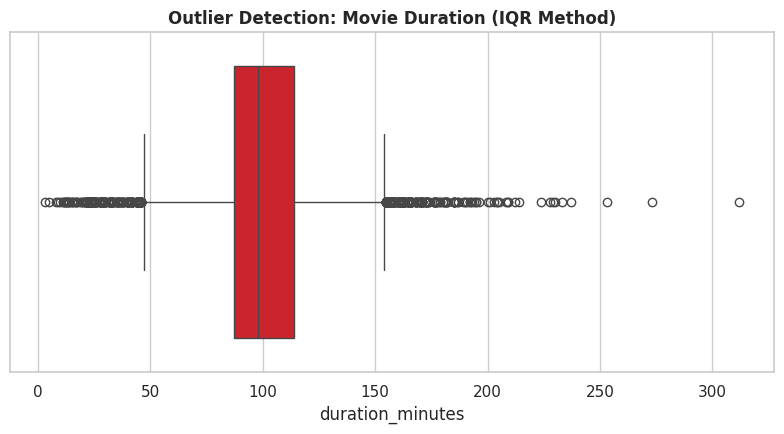

In [25]:
# Outlier detection (IQR method) on movie duration
q1, q3 = movies["duration_minutes"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = movies[(movies["duration_minutes"] < lower) | (movies["duration_minutes"] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}] minutes")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(movies)*100:.2f}% of movies)")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x=movies["duration_minutes"], color=NETFLIX_RED, ax=ax)
ax.set_title("Outlier Detection: Movie Duration (IQR Method)")
plt.tight_layout(); plt.show()

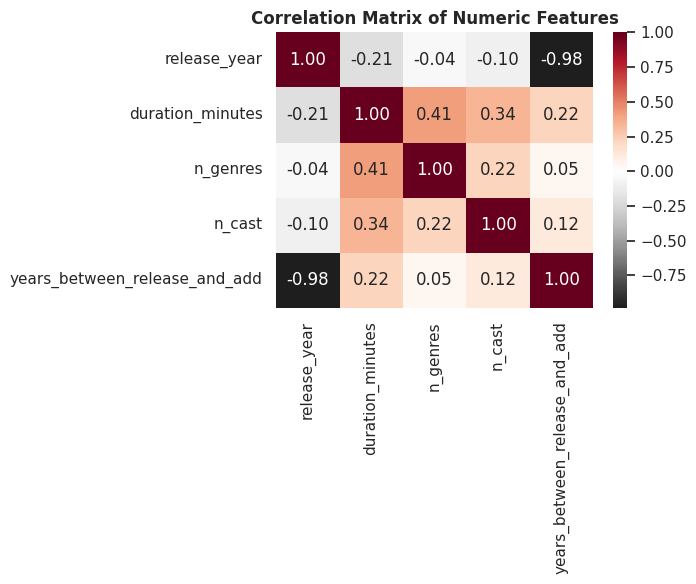

In [26]:
# Correlation matrix of numeric features
num_df = df[["release_year", "duration_minutes", "n_genres", "n_cast", "years_between_release_and_add"]]
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="RdGy_r", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout(); plt.show()

## 8. Dashboard Preparation

The cleaned dataset (`netflix_titles_clean.csv`) is exported for direct use in Power BI. Below we prepare
a few pre-aggregated summary tables that speed up dashboard load time and ensure the DAX layer in Power BI
matches the same logic used in this notebook.

In [27]:
# Pre-aggregated tables for the dashboard layer
summary_by_year = df[df["year_added"] <= 2021].groupby(["year_added", "type"]).size().unstack(fill_value=0)
summary_by_country = df[df["primary_country"] != "Not Specified"]["primary_country"].value_counts().head(20)
summary_by_genre = all_genres.value_counts().head(20)
summary_by_rating = df["rating_group"].value_counts()

summary_by_year.to_csv("summary_by_year.csv")
summary_by_country.to_csv("summary_by_country.csv")
summary_by_genre.to_csv("summary_by_genre.csv")
summary_by_rating.to_csv("summary_by_rating.csv")

print("Dashboard summary tables exported.")

Dashboard summary tables exported.


## 9. Business Insights

- Movie production accelerated sharply from 2016 to 2019 before plateauing.
- The United States dominates the content library, followed distantly by India.
- TV Shows have grown faster in relative terms than Movies since 2018.
- Drama and International Movies are the two largest genre categories by tag count.
- Family-oriented (Kids/Family) content is comparatively limited relative to Adult content.
- Content is typically added to Netflix a median of ~1 year after original release; originals are added
  far faster than licensed catalog titles.
- Most TV shows run only 1–2 seasons, reflecting a limited-series-heavy portfolio strategy.
- Movie runtimes trend modestly shorter over time (statistically significant, though the effect size is small).
- U.S. movies run significantly shorter on average than international movies (~14-minute gap, p < 0.001).
- Content type and country of origin are statistically associated with format mix (chi-square, p < 0.001).


## 10. Recommendations

1. **Invest in underrepresented regions** — no country outside the US/India tops single-digit percentage share.
2. **Expand children's & family programming** — currently under-indexed at under 15% of the library.
3. **Increase multilingual originals** — reduce reliance on licensed international catalog content.
4. **Diversify genre offerings** — niche genres (Sports, Faith & Spirituality) remain thin.
5. **Strengthen regional content strategies** — format preference (movies vs. series) varies significantly
   by country and should inform region-specific investment.


## 11. Conclusion

This notebook demonstrates a complete, reproducible analytics workflow — from a raw, imperfect CSV file
through cleaning, feature engineering, exploratory and statistical analysis, to dashboard-ready summary
tables — culminating in an executive-level PDF report and Power BI dashboard suite.

The full write-up, business interpretation, and dashboard screenshots are available in
`Netflix_Content_Analytics_Report.pdf` in this repository.
